# 04 — RL Market Maker

Train a PPO agent to provide liquidity across all 100 tickers.

**Pipeline:**
1. Generate training environments (one per ticker, using real GARCH sigma)
2. Train PPO agent for N episodes
3. Evaluate: RL spread P&L vs passive baseline
4. Visualise: spread decisions, inventory management, adverse selection
5. Save model → `models/rl_mm_policy.pt`
6. Server auto-loads it on next restart

**Requires:** `pip install torch`  
**GPU optional** — CPU training takes ~5 min for 300 episodes.

In [1]:
import sys, json, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../backend').resolve()))

plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
                      'axes.edgecolor': '#30363d', 'grid.color': '#21262d',
                      'text.color': '#e6edf3', 'axes.labelcolor': '#8b949e',
                      'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
                      'font.family': 'monospace'})

import torch
print(f'PyTorch {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

from engine.rl_environment import MarketMakerEnv, N_STEPS, STATE_DIM, ACTION_DIM
from engine.rl_agent import PPOTrainer, RLMarketMaker
print('Imports OK')

PyTorch 2.5.1+cu121
CUDA: True
Imports OK


In [2]:
# ── Load sigma params for all tickers ────────────────────────────────────
with open('../backend/stock_data/volatility_params.json') as f:
    vol_params = json.load(f)
with open('../backend/stock_data/anchor_prices.json') as f:
    anchors = json.load(f)

from config import TICKER_CAP_MAP, TICKS_PER_SIM_DAY, CAP_PROFILES
import math

# Build per-ticker (anchor, sigma_tick, cap_tier) tuples
ticker_specs = []
for ticker, vp in vol_params.items():
    if ticker not in anchors:
        continue
    raw_sigma = float(vp.get('sigma_daily_adjusted') or vp.get('sigma_daily') or 0.02)
    tier      = TICKER_CAP_MAP.get(ticker, 'mid')
    vol_mult  = CAP_PROFILES[tier]['volatility_multiplier']
    sigma_tick = (raw_sigma * vol_mult) / math.sqrt(TICKS_PER_SIM_DAY)
    ticker_specs.append({
        'ticker':   ticker,
        'anchor':   anchors[ticker],
        'sigma':    sigma_tick,
        'cap_tier': tier,
    })

print(f'Loaded specs for {len(ticker_specs)} tickers')
print(f'Sample: {ticker_specs[:3]}')

Loaded specs for 100 tickers
Sample: [{'ticker': 'AAPL', 'anchor': 263.69, 'sigma': 0.0005514457950869295, 'cap_tier': 'large'}, {'ticker': 'MSFT', 'anchor': 403.79, 'sigma': 0.0005095562966033211, 'cap_tier': 'large'}, {'ticker': 'NVDA', 'anchor': 180.05, 'sigma': 0.0011297835044270033, 'cap_tier': 'large'}]


In [3]:
# ── Define env factory — randomly samples a ticker each episode ─────────
import random

def make_env():
    spec = random.choice(ticker_specs)
    return MarketMakerEnv(
        anchor   = spec['anchor'],
        sigma    = spec['sigma'],
        cap_tier = spec['cap_tier'],
    )

# Quick sanity check — run one episode with random actions
env   = make_env()
state = env.reset(seed=42)
print(f'State shape: {state.shape}, values: {state.round(3)}')

total_r = 0
for _ in range(N_STEPS):
    action = np.random.uniform(-1, 1, ACTION_DIM)
    state, reward, done, info = env.step(action)
    total_r += reward

print(f'Random agent: total_reward={total_r:.4f}, final_pnl=${env.total_pnl:.2f}')

State shape: (8,), values: [0.082 0.    0.    0.    0.    0.5   0.    0.   ]
Random agent: total_reward=-1.3217, final_pnl=$6.70


In [4]:
# ── Train ────────────────────────────────────────────────────────────────
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s')

N_EPISODES = 300   # increase to 500+ for better convergence

trainer = PPOTrainer(lr=3e-4, gamma=0.99, clip_eps=0.2, n_epochs=4)
trainer.train(make_env, n_episodes=N_EPISODES, log_every=20)
print('Training complete')

2026-03-14 21:11:20,241 PPO training: 300 episodes
2026-03-14 21:11:27,441 Ep   20/300 | reward=-2.9133 | pnl=$+23.55 | entropy=2.8140
2026-03-14 21:11:34,513 Ep   40/300 | reward=+7.1817 | pnl=$+30.68 | entropy=2.7801
2026-03-14 21:11:41,233 Ep   60/300 | reward=+3.3146 | pnl=$+33.51 | entropy=2.7894
2026-03-14 21:11:48,086 Ep   80/300 | reward=+9.6680 | pnl=$+30.31 | entropy=2.7835
2026-03-14 21:11:55,017 Ep  100/300 | reward=+1.4141 | pnl=$+28.95 | entropy=2.7689
2026-03-14 21:12:02,192 Ep  120/300 | reward=+4.0197 | pnl=$+21.04 | entropy=2.7382
2026-03-14 21:12:24,797 Ep  140/300 | reward=-0.7784 | pnl=$+38.80 | entropy=2.7392
2026-03-14 21:12:41,790 Ep  160/300 | reward=+0.4649 | pnl=$+31.94 | entropy=2.7039
2026-03-14 21:12:48,637 Ep  180/300 | reward=+12.1203 | pnl=$+67.31 | entropy=2.7016
2026-03-14 21:12:55,205 Ep  200/300 | reward=+9.0230 | pnl=$+45.17 | entropy=2.7085
2026-03-14 21:13:01,844 Ep  220/300 | reward=+5.3385 | pnl=$+29.19 | entropy=2.6914
2026-03-14 21:13:08,359 

Training complete


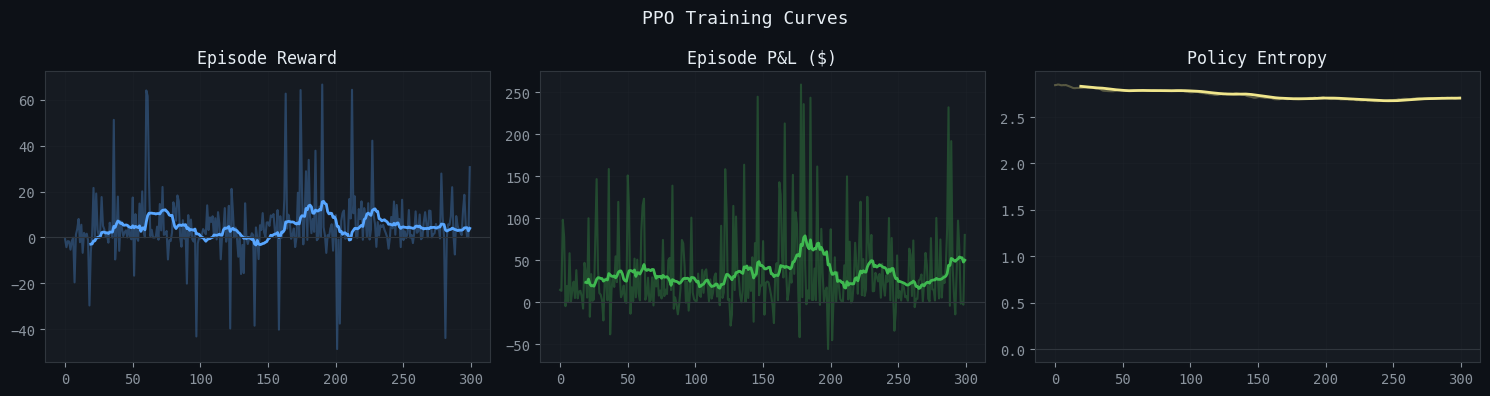

In [5]:
# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PPO Training Curves', fontsize=13)

def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

for ax, key, color, label in [
    (axes[0], 'episode_reward', '#58a6ff', 'Episode Reward'),
    (axes[1], 'episode_pnl',    '#3fb950', 'Episode P&L ($)'),
    (axes[2], 'entropy',        '#f0e68c', 'Policy Entropy'),
]:
    raw = trainer.history[key]
    ax.plot(raw, alpha=0.3, color=color)
    if len(raw) >= 20:
        ax.plot(range(19, len(raw)), smooth(raw), color=color, lw=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='#30363d', lw=0.8)

plt.tight_layout()
plt.savefig('04_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

RL agent:      mean P&L = $+29.77  (std=45.18)
Passive MM:    mean P&L = $+17.31  (std=40.90)
RL advantage:  $+12.46 per episode


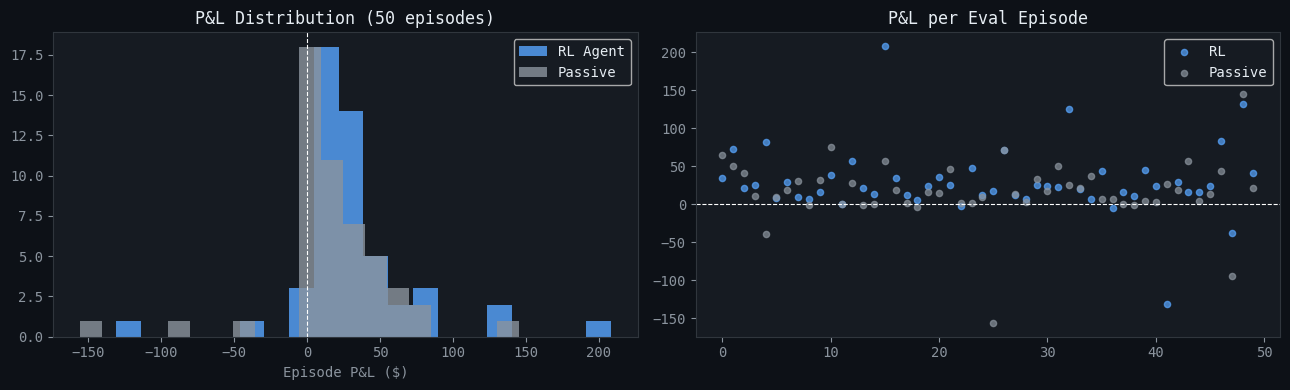

In [6]:
# ── Evaluate: RL vs Passive baseline ─────────────────────────────────────
N_EVAL = 50

rl_pnls      = []
passive_pnls = []

for seed in range(N_EVAL):
    spec = ticker_specs[seed % len(ticker_specs)]
    base_spread = CAP_PROFILES[spec['cap_tier']]['spread_pct']

    # RL agent
    env = MarketMakerEnv(anchor=spec['anchor'], sigma=spec['sigma'], cap_tier=spec['cap_tier'])
    state = env.reset(seed=seed)
    for _ in range(N_STEPS):
        action, _, _ = trainer.policy.get_action(state)
        state, _, done, _ = env.step(action)
        if done: break
    rl_pnls.append(env.total_pnl)

    # Passive baseline: fixed spread, no lean
    env2  = MarketMakerEnv(anchor=spec['anchor'], sigma=spec['sigma'], cap_tier=spec['cap_tier'])
    state = env2.reset(seed=seed)
    for _ in range(N_STEPS):
        state, _, done, _ = env2.step(np.array([0.0, 0.0]))  # neutral action
        if done: break
    passive_pnls.append(env2.total_pnl)

print(f'RL agent:      mean P&L = ${np.mean(rl_pnls):+.2f}  (std={np.std(rl_pnls):.2f})')
print(f'Passive MM:    mean P&L = ${np.mean(passive_pnls):+.2f}  (std={np.std(passive_pnls):.2f})')
print(f'RL advantage:  ${np.mean(rl_pnls) - np.mean(passive_pnls):+.2f} per episode')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(rl_pnls,      bins=20, alpha=0.8, color='#58a6ff', label='RL Agent')
axes[0].hist(passive_pnls, bins=20, alpha=0.8, color='#8b949e', label='Passive')
axes[0].axvline(0, color='white', lw=0.8, ls='--')
axes[0].set_title('P&L Distribution (50 episodes)')
axes[0].set_xlabel('Episode P&L ($)')
axes[0].legend()

axes[1].scatter(range(N_EVAL), rl_pnls,      s=20, color='#58a6ff', alpha=0.7, label='RL')
axes[1].scatter(range(N_EVAL), passive_pnls, s=20, color='#8b949e', alpha=0.7, label='Passive')
axes[1].axhline(0, color='white', lw=0.8, ls='--')
axes[1].set_title('P&L per Eval Episode')
axes[1].legend()

plt.tight_layout()
plt.savefig('04_rl_vs_passive.png', dpi=120, bbox_inches='tight')
plt.show()

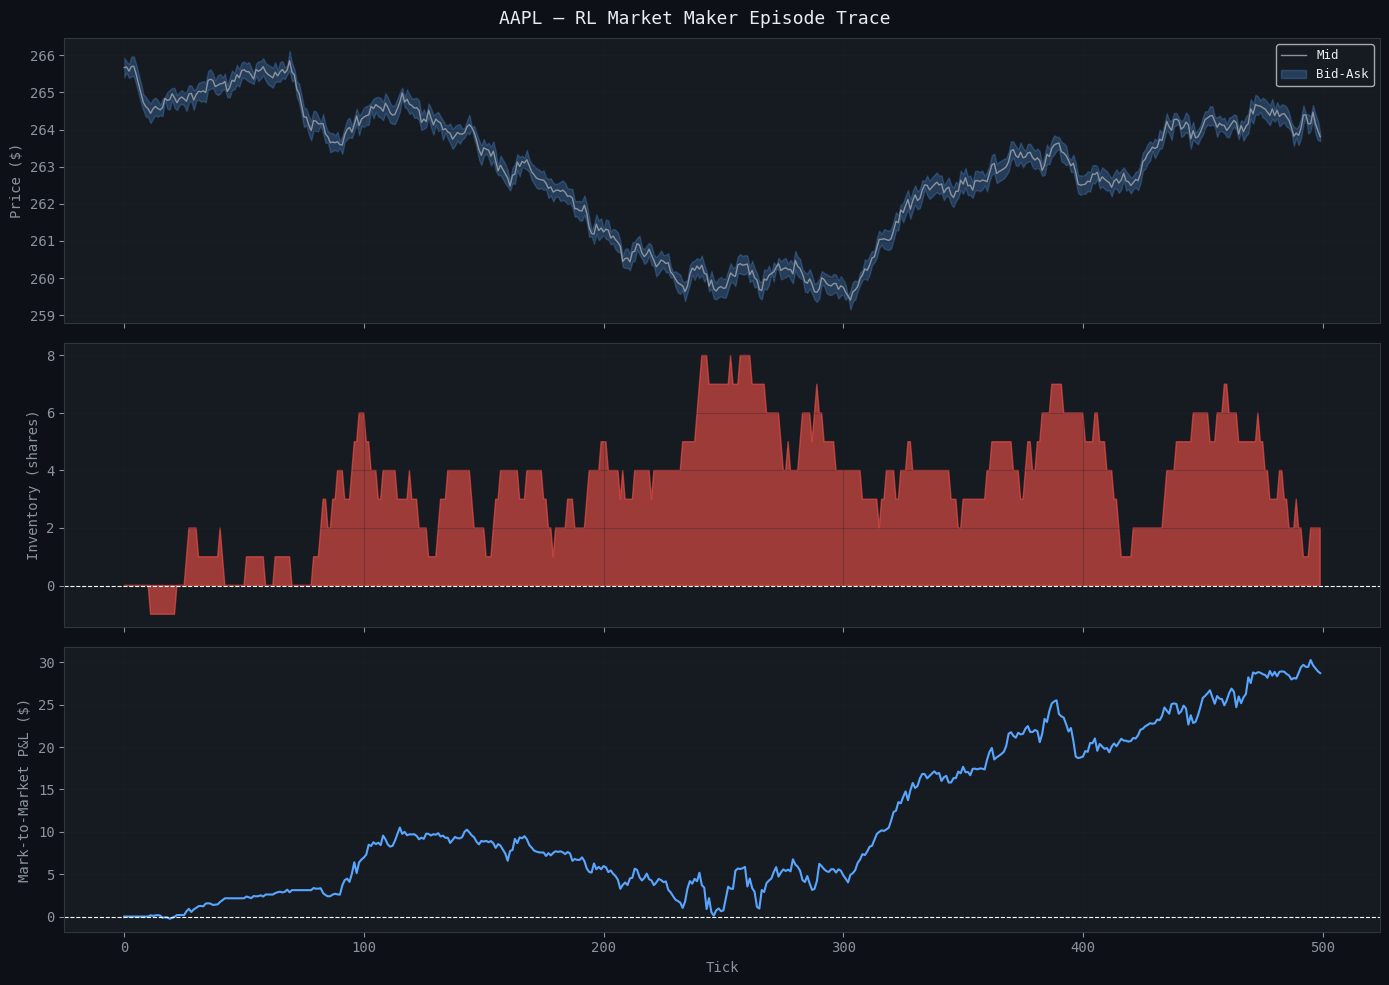

Spread range: 0.0 – 20.0 bps
Mean spread:  17.0 bps
Max inventory: 8 shares
Final P&L: $28.73


In [7]:
# ── Inspect agent behaviour: one episode trace ────────────────────────────
spec  = next(s for s in ticker_specs if s['ticker'] == 'AAPL')
env   = MarketMakerEnv(anchor=spec['anchor'], sigma=spec['sigma'], cap_tier=spec['cap_tier'])
state = env.reset(seed=7)

trace = {'mid': [], 'bid': [], 'ask': [], 'inventory': [], 'pnl': [], 'spread': []}

for _ in range(N_STEPS):
    action, _, _ = trainer.policy.get_action(state)
    state, reward, done, info = env.step(action)
    trace['mid'].append(env.prices[env.tick - 1])
    trace['bid'].append(info['bid'])
    trace['ask'].append(info['ask'])
    trace['inventory'].append(info['inventory'])
    trace['pnl'].append(info['total_pnl'])
    trace['spread'].append(info['spread'] * 10000)  # bps
    if done: break

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('AAPL — RL Market Maker Episode Trace', fontsize=13)

# Price + quotes
axes[0].plot(trace['mid'], color='#8b949e', lw=1, label='Mid')
axes[0].fill_between(range(len(trace['bid'])), trace['bid'], trace['ask'],
                     alpha=0.25, color='#58a6ff', label='Bid-Ask')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Inventory
axes[1].fill_between(range(len(trace['inventory'])), trace['inventory'],
                     alpha=0.6,
                     color=['#3fb950' if x > 0 else '#f85149' for x in trace['inventory']])
axes[1].axhline(0, color='white', lw=0.8, ls='--')
axes[1].set_ylabel('Inventory (shares)')
axes[1].grid(True, alpha=0.3)

# P&L
pnl_color = ['#3fb950' if p >= 0 else '#f85149' for p in trace['pnl']]
axes[2].plot(trace['pnl'], color='#58a6ff', lw=1.5)
axes[2].axhline(0, color='white', lw=0.8, ls='--')
axes[2].set_ylabel('Mark-to-Market P&L ($)')
axes[2].set_xlabel('Tick')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_episode_trace.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Spread range: {min(trace["spread"]):.1f} – {max(trace["spread"]):.1f} bps')
print(f'Mean spread:  {np.mean(trace["spread"]):.1f} bps')
print(f'Max inventory: {max(abs(i) for i in trace["inventory"]):.0f} shares')
print(f'Final P&L: ${trace["pnl"][-1]:.2f}')

In [8]:
# ── Save model ───────────────────────────────────────────────────────────
MODEL_PATH = Path('../backend/models/rl_mm_policy.pt')
trainer.save(MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')
print()
print('Restart the backend server to activate the RL market maker:')
print('  python -m uvicorn main:app --reload --port 8000')
print()
print('You will see this log line on startup:')
print('  Market maker mode: RL AGENT')

2026-03-14 21:14:16,424 Policy saved → ..\backend\models\rl_mm_policy.pt


Model saved to ..\backend\models\rl_mm_policy.pt

Restart the backend server to activate the RL market maker:
  python -m uvicorn main:app --reload --port 8000

You will see this log line on startup:
  Market maker mode: RL AGENT
